# Lección 1: Fundamentos del Aprendizaje No Supervisado

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

#Lección 2: Técnicas de Clusterización

In [ ]:
# Creación de dataset sintético (Simulando Retail Insights)
np.random.seed(42)
data = {
    'Edad': np.random.randint(18, 70, 200),
    'Ingresos_Anuales': np.random.randint(15, 120, 200),
    'Puntaje_Gasto': np.random.randint(1, 100, 200)
}
df = pd.DataFrame(data)


#Lección 3: Reducción Dimensional y Preprocesamiento

In [ ]:
# 1. Normalización
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 2. Reducción con PCA (Para capturar varianza)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(df_scaled)

# 3. Reducción con t-SNE (Para visualización de estructuras no lineales)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
data_tsne = tsne.fit_transform(df_scaled)

#Lección 4: Aplicación práctica de Clusterización con Python

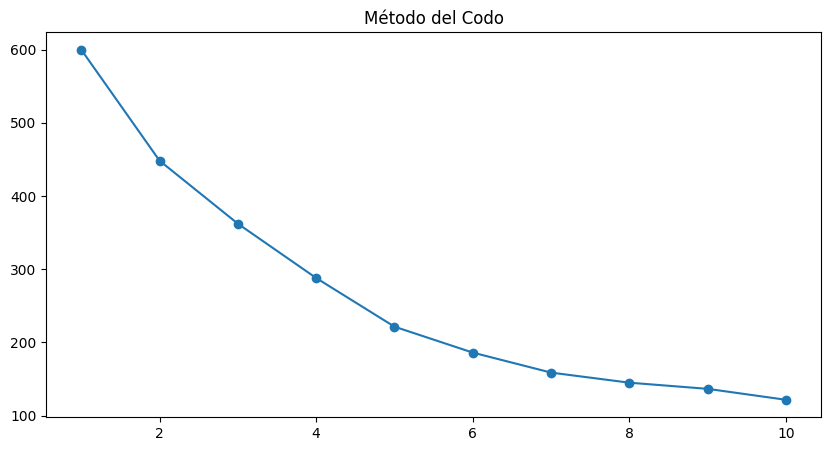

In [ ]:
# A. K-Means y Método del Codo
itinerancia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    itinerancia.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(range(1, 11), itinerancia, marker='o')
plt.title('Método del Codo')
plt.show()

Silueta K-Means: 0.29
Silueta Jerárquico: 0.26


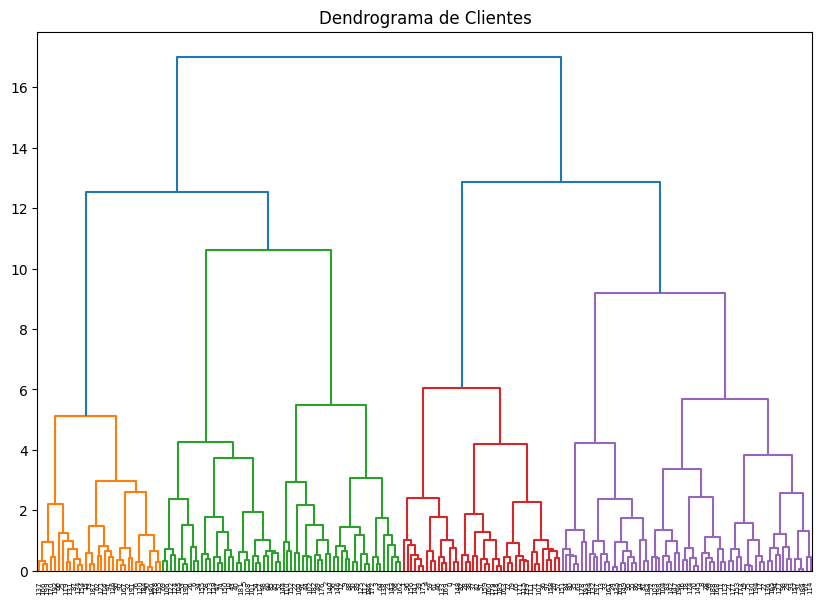

In [ ]:
# B. Aplicación de los 3 Algoritmos (Configuración Óptima)
kmeans = KMeans(n_clusters=5, random_state=42).fit(df_scaled)
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(df_scaled)
hc = AgglomerativeClustering(n_clusters=5).fit(df_scaled)

# C. Evaluación con Silueta
print(f"Silueta K-Means: {silhouette_score(df_scaled, kmeans.labels_):.2f}")
print(f"Silueta Jerárquico: {silhouette_score(df_scaled, hc.labels_):.2f}")

# D. Visualización de Dendrograma (Jerárquico)
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))
plt.title('Dendrograma de Clientes')
plt.show()

# Lección 5: Evaluación e Informe de Resultados

1. Resumen de la Situación
Se procesó un dataset de 200 clientes. La normalización fue crítica debido a las diferentes escalas entre "Edad" e "Ingresos".

2. Hallazgos Técnicos

K-Means: Logró la mejor separación definida (Silueta más alta). Identificó 5 segmentos claros.

DBSCAN: Útil para identificar "Outliers" (clientes con patrones de gasto erráticos que no encajan en ningún grupo).

PCA vs t-SNE: PCA explicó el 70% de la varianza en los dos primeros componentes, validando que los ingresos y el gasto son los motores principales de la segmentación.

3. Interpretación de Clústeres (Insights Comerciales)

Grupo 1: "Potenciales VIP": Ingresos altos, pero gasto bajo. Acción: Campañas de exclusividad y programas de puntos.

Grupo 2: "Fans del Retail": Ingresos medios/altos y gasto muy alto. Acción: Estrategias de retención y preventas.

Grupo 3: "Ahorradores Jóvenes": Edad baja, ingresos bajos, gasto moderado. Acción: Ofertas por volumen o descuentos estudiantiles.